In [3]:
# Step 1: Install and import dependencies
!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download AAPL adjusted closing prices for the last 5 years
ticker = "AAPL"
df = yf.download(ticker, start="2021-01-01", end="2026-01-01", auto_adjust=True)

# Keep only the Close price (auto_adjust=True already gives adjusted prices)
prices = df["Close"].dropna()

print(f"Downloaded {len(prices)} trading days of data")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"\nFirst 5 rows:\n{prices.head()}")
print(f"\nLast 5 rows:\n{prices.tail()}")

[*********************100%***********************]  1 of 1 completed

Downloaded 1255 trading days of data
Date range: 2021-01-04 to 2025-12-31

First 5 rows:
Ticker            AAPL
Date                  
2021-01-04  125.856697
2021-01-05  127.412743
2021-01-06  123.123848
2021-01-07  127.325264
2021-01-08  128.424194

Last 5 rows:
Ticker            AAPL
Date                  
2025-12-24  273.554016
2025-12-26  273.144409
2025-12-29  273.504089
2025-12-30  272.824707
2025-12-31  271.605835


In [4]:
# Step 2: Data Preprocessing

# Compute daily log returns
returns = np.log(prices / prices.shift(1)).dropna()

# Check for missing values
print(f"Missing values: {returns.isna().sum()}")
print(f"Total trading days: {len(returns)}")

# Summary statistics
print(f"\nReturn Statistics:")
print(returns.describe().round(5))

Missing values: Ticker
AAPL    0
dtype: int64
Total trading days: 1254

Return Statistics:
Ticker        AAPL
count   1254.00000
mean       0.00061
std        0.01749
min       -0.09701
25%       -0.00797
50%        0.00110
75%        0.00979
max        0.14262


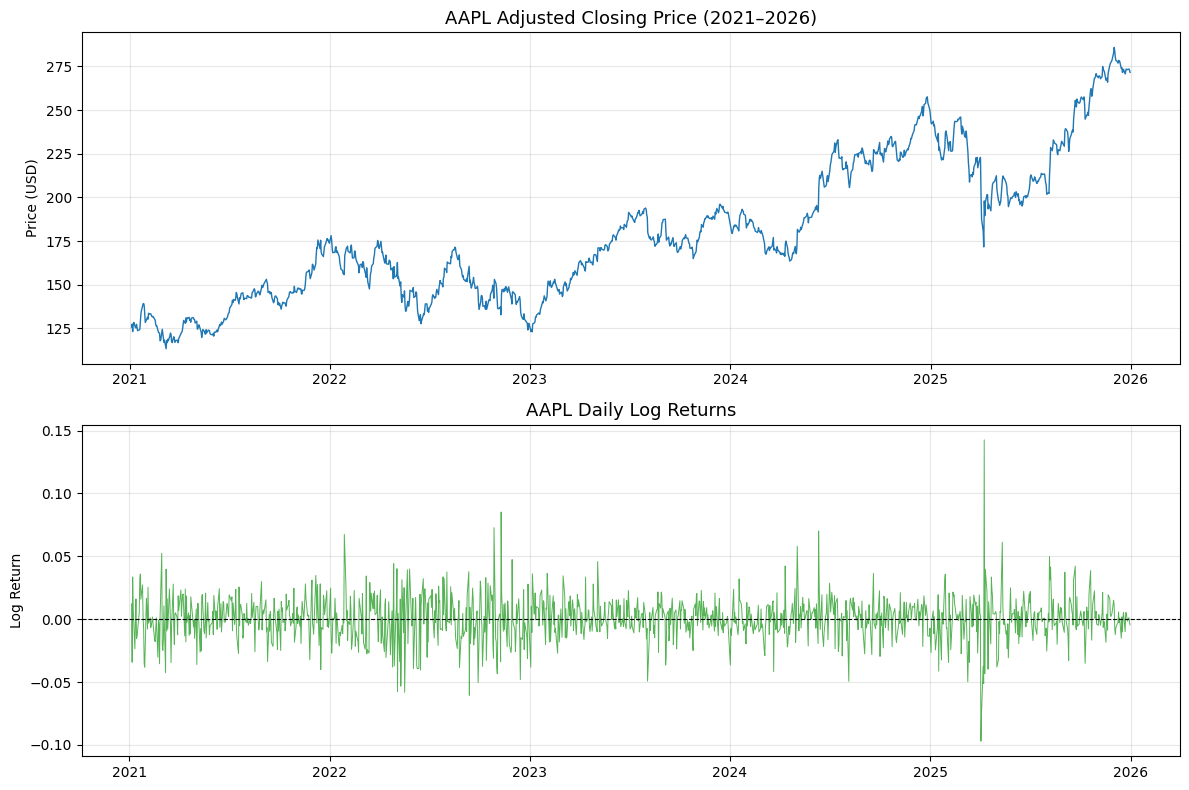

Preprocessing complete. 1254 daily returns computed.


In [5]:
# Plot 1: Price history
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(prices.index, prices.values, color="#1f77b4", linewidth=1)
axes[0].set_title("AAPL Adjusted Closing Price (2021–2026)", fontsize=13)
axes[0].set_ylabel("Price (USD)")
axes[0].grid(alpha=0.3)

# Plot 2: Daily returns
axes[1].plot(returns.index, returns.values, color="#2ca02c", linewidth=0.7, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("AAPL Daily Log Returns", fontsize=13)
axes[1].set_ylabel("Log Return")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Preprocessing complete. {len(returns)} daily returns computed.")

In [7]:
# Step 3: Model Fitting — Linear Regression on Lagged Returns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- Feature Engineering: create 5 lagged return features ---
LAGS = 5
df_model = pd.DataFrame({"r": returns.squeeze().values}, index=returns.index)  # .squeeze() fixes the shape issue

for lag in range(1, LAGS + 1):
    df_model[f"lag_{lag}"] = df_model["r"].shift(lag)

df_model = df_model.dropna()

X = df_model[[f"lag_{i}" for i in range(1, LAGS + 1)]].values
y = df_model["r"].values
dates = df_model.index

# --- Chronological 80/20 train/test split (no shuffling for time series!) ---
split_idx = int(len(X) * 0.80)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_train = dates[:split_idx]
dates_test  = dates[split_idx:]

print(f"Training samples : {len(X_train)} ({dates_train[0].date()} to {dates_train[-1].date()})")
print(f"Testing samples  : {len(X_test)}  ({dates_test[0].date()} to {dates_test[-1].date()})")

# --- Train the model ---
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Training samples : 999 (2021-01-12 to 2024-12-31)
Testing samples  : 250  (2025-01-02 to 2025-12-31)


In [8]:
# --- Evaluate ---
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = model.score(X_test, y_test)

print(f"\nModel Evaluation on Test Set:")
print(f"  RMSE : {rmse:.6f}")
print(f"  MAE  : {mae:.6f}")
print(f"  R²   : {r2:.4f}")


Model Evaluation on Test Set:
  RMSE : 0.020411
  MAE  : 0.012891
  R²   : -0.0158


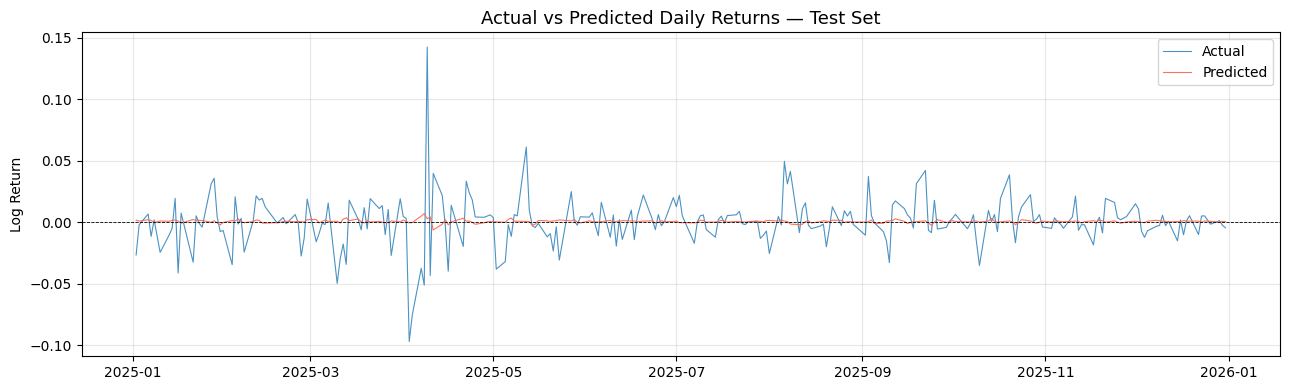

In [9]:
#  Plot actual vs predicted
plt.figure(figsize=(13, 4))
plt.plot(dates_test, y_test, color="#1f77b4", linewidth=0.8, alpha=0.8, label="Actual")
plt.plot(dates_test, y_pred, color="tomato",  linewidth=0.8, alpha=0.9, label="Predicted")
plt.axhline(0, color="black", linewidth=0.6, linestyle="--")
plt.title("Actual vs Predicted Daily Returns — Test Set", fontsize=13)
plt.ylabel("Log Return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

   FINANCIAL METRICS — AAPL Test Period
  Period        : 2025-01-02 to 2025-12-31
  Trading Days  : 250
  Risk-Free Rate: 4.3% annualised
  Annual Return : 9.13%
  Sharpe Ratio  : 0.2969
  Sortino Ratio : 0.3068


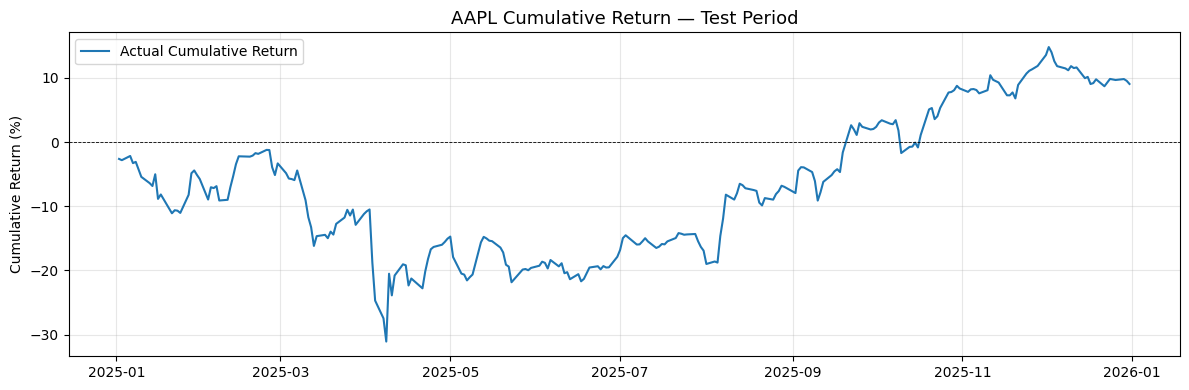

In [11]:
# Financial Metric Computation on Test Set

RISK_FREE_RATE_ANNUAL = 0.043  # 4.3% annualised
TRADING_DAYS = 252

# Use simple returns for metrics (more straightforward)
simple_test = np.exp(y_test) - 1
rf_daily = RISK_FREE_RATE_ANNUAL / TRADING_DAYS
excess_returns = simple_test - rf_daily

# --- Annual Return ---
cumulative_return = np.prod(1 + simple_test) - 1
n_years = len(simple_test) / TRADING_DAYS
annual_return = (1 + cumulative_return) ** (1 / n_years) - 1

# --- Sharpe Ratio ---
sharpe_ratio = (excess_returns.mean() / excess_returns.std()) * np.sqrt(TRADING_DAYS)

# --- Sortino Ratio ---
downside_returns = excess_returns[excess_returns < 0]
downside_std = np.sqrt((downside_returns ** 2).mean())
sortino_ratio = (excess_returns.mean() / downside_std) * np.sqrt(TRADING_DAYS)

# --- Print Results ---
print("   FINANCIAL METRICS — AAPL Test Period")
print(f"  Period        : {dates_test[0].date()} to {dates_test[-1].date()}")
print(f"  Trading Days  : {len(simple_test)}")
print(f"  Risk-Free Rate: {RISK_FREE_RATE_ANNUAL*100:.1f}% annualised")
print(f"  Annual Return : {annual_return*100:.2f}%")
print(f"  Sharpe Ratio  : {sharpe_ratio:.4f}")
print(f"  Sortino Ratio : {sortino_ratio:.4f}")

# --- Cumulative return plot ---
plt.figure(figsize=(12, 4))
cum_actual = (np.cumprod(1 + simple_test) - 1) * 100
plt.plot(dates_test, cum_actual, color="#1f77b4", linewidth=1.5, label="Actual Cumulative Return")
plt.axhline(0, color="black", linewidth=0.6, linestyle="--")
plt.title("AAPL Cumulative Return — Test Period", fontsize=13)
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()